For this example, we'll use the Python libraries **pandas** and **scikit-learn**. Briefly, **pandas** allows us to read and manipulate data, while **scikit-learn** helps us train supervised learning algorithms for classification and regression problems.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import accuracy_score, recall_score, precision_score

# Example

In this demo, we will show how to work with classification problems using Logistic Regression. To this end, we use the banknote data set in the file "banknotes.xlsx".


In [ ]:
# Read data into python.
bank_data = pd.read_excel("banknotes.xlsx")

# Set the categorical variables.
bank_data['Status'] = pd.Categorical(bank_data['Status'])

# Show dataset.
bank_data

,Status,Left,Right,Bottom,Top
0,genuine,131.0,131.1,9.0,9.7
1,genuine,129.7,129.7,8.1,9.5
2,genuine,129.7,129.7,8.7,9.6
3,genuine,129.7,129.6,7.5,10.4
4,genuine,129.6,129.7,10.4,7.7
...,...,...,...,...,...
195,counterfeit,130.4,130.3,9.9,12.1
196,counterfeit,130.3,129.9,10.3,11.5
197,counterfeit,130.3,130.4,10.6,11.1
198,counterfeit,130.7,130.8,11.2,11.2


## Trainning and validation data

To construct and evaluate the classification methods, we will split the data into two parts. One will serve as training data while the other as validation data. To do this, we use the function ``train_test_split()`` in **scikit-learn**. We will assign 70% of the data for training. The other 30% will go to the validation data. To this end, we first need to create some pandas objects.


In [ ]:
# Set full matrix of predictors.
X_full = bank_data.filter(['Bottom', 'Top'])

# Set full matrix of responses.
Y_full = bank_data['Status']

Next, we set the target category in the response we use the `get_dummies()` function.

In [ ]:
# Create dummy variables.
Y_dummies = pd.get_dummies(Y_full, dtype = 'int')
Y_dummies

,counterfeit,genuine
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
...,...,...
195,1,0
196,1,0
197,1,0
198,1,0


Next, we select the target variable.

In [ ]:
# Select target variable.
Y_target_full = Y_dummies['counterfeit']

# Show target variable.
Y_target_full

,counterfeit
0,0
1,0
2,0
3,0
4,0
...,...
195,1
196,1
197,1
198,1


Now, we are ready to split the dataset.

In [ ]:
# Split the dataset into training and validation.
X_train, X_valid, Y_train, Y_valid = train_test_split(X_full, Y_target_full,
                                                      stratify = Y_target_full,
                                                      test_size = 0.3)

Some comments are as follows:

-   The function makes a clever partition of the data using the *empirical* distribution of the response.

-   Technically, it splits the data so that the distribution of the response under the training and validation sets is similar.

-   Usually, the proportion of the dataset that goes to the validation set is 20% or 30%.


After we have partitioned the data, we **work on the training data** to develop our predictive pipeline.

# Decision trees

## Classification trees

In Python, we can use the `DecisionTreeClassifier()` and `fit()` functions from **scikit-learn** to train a decision tree. The parameter `min_samples_leaf` of `DecisionTreeClassifier()` controls the minimum number of observations in a terminal node, and the `cc_alpha` controls the cost complexity parameter (to be described later). The parameter `random_state` allows you to reproduce the same tree in different runs of the Python code.

In [ ]:
# We tell Python we want a classification tree
clf = DecisionTreeClassifier(min_samples_leaf = 5, ccp_alpha=0, random_state=507134)

# We train the classification tree using the training data.
clf.fit(X_train, Y_train)

DecisionTreeClassifier(ccp_alpha=0, min_samples_leaf=5, random_state=507134)

To see the decision tree, we use the `plot_tree` function from **scikit-learn** and some commands from **matplotlib**. Specifically, we use the `plt.figure()` functions to define the size of the figure and `plt.show()` to display the figure.

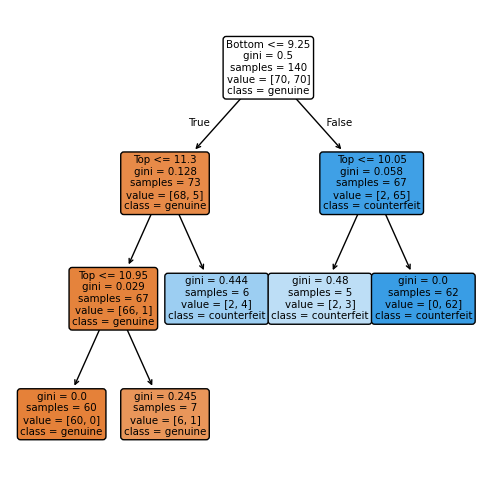

In [ ]:
plt.figure(figsize=(6, 6))
plot_tree(clf, feature_names = X_train.columns,
          class_names=["genuine", "counterfeit"],
          filled=True, rounded=True)
plt.show()

# Evaluation of Classification Algorithms

We evaluate a classification tree by classifying observations that were not used for training. That is, we use the classifier to predict categories in the validation data set using only the predictor values from this set. In Python, we use the commands:

In [ ]:
# Predict classes.
predicted_class = clf.predict(X_valid)
predicted_class

array([1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1])

The `predict()` function generates actual classes to which each observation was assigned. The `predict_proba()` function generates the probabilities used by the algorithm to assign the classes.

In [ ]:
# Predict probabilities.
predicted_probability = clf.predict_proba(X_valid)
predicted_probability

array([[0.33333333, 0.66666667],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.4       , 0.6       ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [0.4       , 0.6       ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.4       , 0.6       ],
       [1.        , 0.        ],
       [1.

To evaluate the performance of the classification tree, we use the confusion matrix.

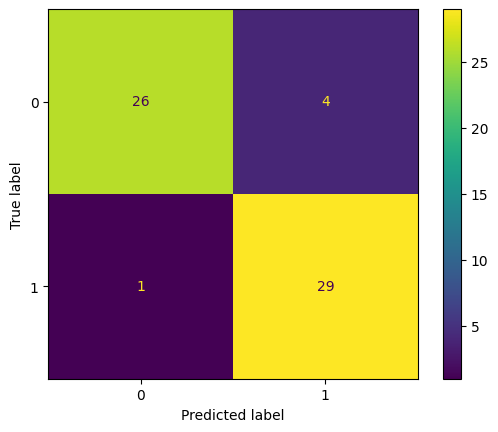

In [ ]:
# Compute confusion matrix.
cm = confusion_matrix(Y_valid, predicted_class)

# Show confusion matrix.
ConfusionMatrixDisplay(cm).plot()

Recall that a simple metric to summarize the information of the confusion matrix is **accuracy**. In Python, we compute the accuracy using the function `accuracy_score()` from **scikit-learn**.


In [ ]:
accuracy = accuracy_score(Y_valid, predicted_class)
print( round(accuracy, 2) )

0.92


## Cost Complexity Prunning

In the following code, we will use the pruning technique to find a small decision tree that performs well on unobserved data. To do this, we will train several decision trees using different values of the $\alpha$ parameter, which weighs the contribution of the tree branches.

In Python, this is achieved using the `cost_complexity_pruning_path()` function with the following syntax.

In [ ]:
path = clf.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas

array([0.        , 0.0018276 , 0.01057569, 0.03341609, 0.40574525])

The `ccp_alphas` object contains the different values of the $\alpha$ parameter used.

To train a decision tree using different alpha values, we use the following code that iterates over the values contained in `ccp_alphas`.


In [ ]:
# 1. Define the grid of parameters
param_grid = {'ccp_alpha': ccp_alphas}

# 2. Set the classification trees using 5-fold CV.
grid_search = GridSearchCV(
    DecisionTreeClassifier(min_samples_leaf = 5, random_state = 507134),
    param_grid,
    cv = 5,
    scoring = 'accuracy'
)

# 3. Train the classification algorithms
grid_search.fit(X_train, Y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(min_samples_leaf=5,
                                              random_state=507134),
             param_grid={'ccp_alpha': array([0.        , 0.0018276 , 0.01057569, 0.03341609, 0.40574525])},
             scoring='accuracy')

Now, extract the results.

In [ ]:
best_alpha = grid_search.best_params_['ccp_alpha']
cv_scores = grid_search.cv_results_['mean_test_score']

print(f"Best Alpha: {best_alpha}")

Best Alpha: 0.0


The `best_alpha` is the optimal value of the cost complexity parameter ($\alpha$). The `cv_scores` shows the estimates of accuracy given by the 5-fold cross-validation.

In [ ]:
cv_scores

array([0.94285714, 0.94285714, 0.94285714, 0.94285714, 0.67142857])

We visualize the results using the following plot.

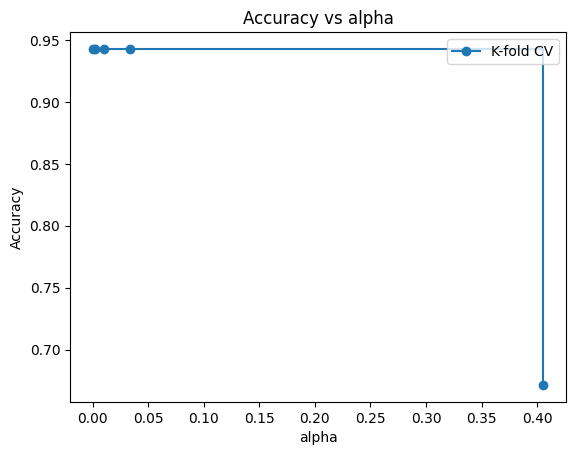

In [ ]:
fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs alpha")
ax.plot(ccp_alphas, cv_scores, marker="o", label="K-fold CV", drawstyle="steps-post")
ax.legend()
plt.show()

We can see that the best $\alpha$ value for the validation dataset is 0.

To train our new reduced tree, we use the `DecisionTreeClassifier()` function again with the `ccp_alpha` parameter set to the best $\alpha$ value. The object containing this new tree is `clf_simple`.

In [ ]:
# We tell Python that we want a classification tree
clf_simple = DecisionTreeClassifier(min_samples_leaf= 5, ccp_alpha=best_alpha,
                                    random_state = 507134)

# We train the classification tree using the training data.
clf_simple.fit(X_train, Y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0), min_samples_leaf=5)

Once this is done, we can visualize the small tree using the `plot_tree()` function.

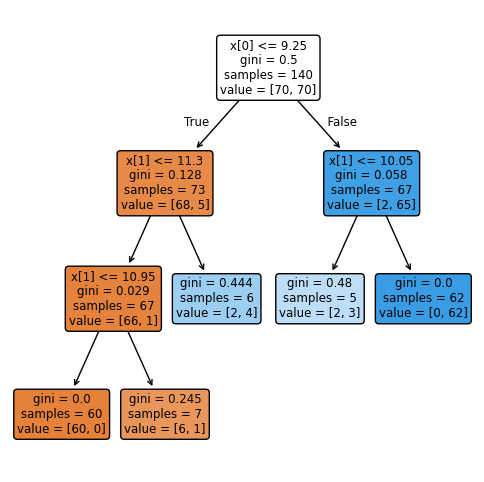

In [ ]:
plt.figure(figsize=(6, 6))
plot_tree(clf_simple, filled=True, rounded=True)
plt.show()

We evaluate the performance of the optimal tree using its accuracy.

In [ ]:
single_tree_Y_pred = clf_simple.predict(X_valid)
accuracy = accuracy_score(Y_valid, single_tree_Y_pred)
print( round(accuracy, 2) )

0.92


## Other classification metrics

There are several class-specific metrics that are alternatives to the accuracy. The most popular are:

-   Sensitivity or *recall*

-   Precision

-   Type I error

These metrics are calculated from the confusion matrix. In Python, we compute them using the following commands.

In [ ]:
recall = recall_score(Y_valid, predicted_class)
print( round(recall, 2) )

In [ ]:
precision = precision_score(Y_valid, predicted_class)
print( round(precision, 2) )

In [ ]:
# Confusion matrix to compute Type-I error
tn, fp, fn, tp = confusion_matrix(Y_valid, predicted_class).ravel()

# Type-I error rate = False Positive Rate = FP / (FP + TN)
type_I_error = fp / (fp + tn)
print( round(type_I_error, 2) )